# Q3 – Subject-Specific Resilience to Deprivation

Research Question:
Are some EBacc subjects more resilient to deprivation than others?
A subject is more resilient to deprivation if its performance declines less as deprivation increases.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import dataframe_image as dfi

In [4]:
file_path = "data/total_geo_agg.csv"
df_q3 = pd.read_csv(file_path)

In [5]:
# keeping only nessesary for q3 columns
df_q3 = df_q3[[
    "time_period",
    "la_name",
    "ebacceng_aps_average",
    "ebaccmat_aps_average",
    "ebaccsci_aps_average",
    "ebacchum_aps_average",
    "ebacclan_aps_average",
    'ebacceng_entering_percent',
    'ebaccmat_entering_percent', 
    'ebaccsci_entering_percent',
    'ebacchum_entering_percent',
    'ebacclan_entering_percent',
    "imd_score",
    "pct_highly_deprived"
    ]].sort_values(["la_name","time_period"])


In [6]:
subjects = [
    "ebacceng_aps_average",
    "ebaccmat_aps_average",
    "ebaccsci_aps_average",
    "ebacchum_aps_average",
    "ebacclan_aps_average"
]
entering = [
    'ebacceng_entering_percent',
    'ebaccmat_entering_percent', 
    'ebaccsci_entering_percent',
    'ebacchum_entering_percent',
    'ebacclan_entering_percent'
]

# creating more meaningful names for columns to show in all tables and plots 
subject_names = {
    "ebacceng_aps_average": "English",
    "ebaccmat_aps_average": "Maths",
    "ebaccsci_aps_average": "Science",
    "ebacchum_aps_average": "Humanities",
    "ebacclan_aps_average": "Languages",
    'ebacceng_entering_percent': "Eng entering %",
    'ebaccmat_entering_percent': "Math entering %", 
    'ebaccsci_entering_percent': "Sci entering %",
    'ebacchum_entering_percent': "Hum entering %",
    'ebacclan_entering_percent': "Lang entering %"
}

### Exploratory analysis

In [7]:
#print(df_q3.columns)
print(df_q3[subjects + entering + ["imd_score", "pct_highly_deprived"]].isnull().sum())
df_q3[subjects + entering + ["imd_score"]].describe().round(2)

ebacceng_aps_average         0
ebaccmat_aps_average         0
ebaccsci_aps_average         0
ebacchum_aps_average         0
ebacclan_aps_average         0
ebacceng_entering_percent    0
ebaccmat_entering_percent    0
ebaccsci_entering_percent    0
ebacchum_entering_percent    0
ebacclan_entering_percent    0
imd_score                    0
pct_highly_deprived          0
dtype: int64


,ebacceng_aps_average,ebaccmat_aps_average,ebaccsci_aps_average,ebacchum_aps_average,ebacclan_aps_average,ebacceng_entering_percent,ebaccmat_entering_percent,ebaccsci_entering_percent,ebacchum_entering_percent,ebacclan_entering_percent,imd_score
count,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00
mean,5.05,4.67,4.61,3.91,2.39,94.94,96.83,95.03,81.48,46.14,23.00
std,0.40,0.43,0.46,0.50,0.72,1.84,1.09,1.88,4.31,11.30,8.06
min,3.66,3.19,3.02,2.25,0.90,84.40,88.20,74.70,65.50,20.40,5.85
25%,4.78,4.40,4.30,3.57,1.89,94.05,96.30,94.12,78.90,38.00,16.79
50%,5.01,4.61,4.55,3.86,2.20,95.20,97.00,95.35,82.10,43.80,22.48
75%,5.28,4.92,4.91,4.24,2.78,96.20,97.60,96.30,84.50,52.65,27.96
max,6.29,6.12,6.10,5.51,4.52,99.00,99.20,98.50,91.80,80.30,45.04


The dataset contains 1,043 Local Authority-year observations with no missing values in the variables used for this analysis.

Average APS scores vary across subjects, with English showing the highest mean score (5.05) and Languages the lowest (2.39). IMD scores range from 5.85 to 45.04, indicating substantial variation in deprivation levels across Local Authorities.

Subject participation rates also vary considerably. Entry rates are very high for English, Maths and Science (around 95%), reflecting their status as core GCSE subjects. Participation is lower for Humanities (81%) and substantially lower for Languages (46%), which are optional subjects for many pupils.

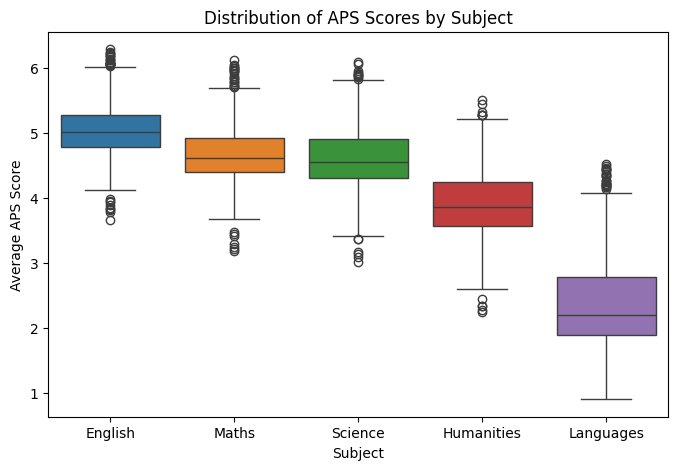

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_q3[subjects].rename(columns=subject_names))
plt.title("Distribution of APS Scores by Subject")
plt.xlabel("Subject")
plt.ylabel("Average APS Score")
plt.show()

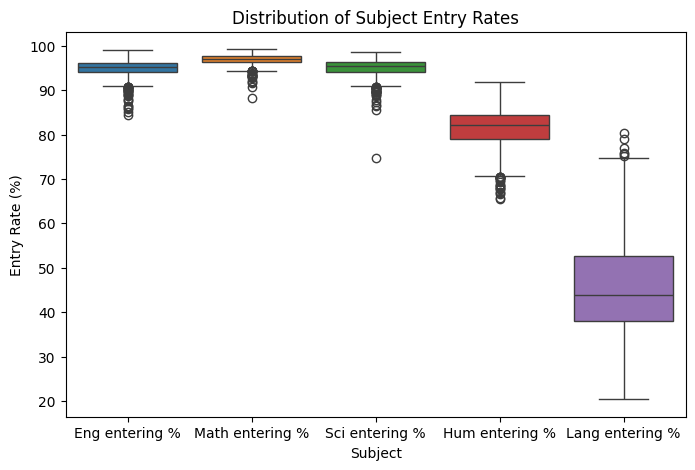

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_q3[entering].rename(columns=subject_names))
plt.title("Distribution of Subject Entry Rates")
plt.xlabel("Subject")
plt.ylabel("Entry Rate (%)")
plt.show()


Boxplots were used to examine the distribution of APS scores and subject entry rates. Several observations fall outside the whiskers of the boxplots. These are likely to reflect genuine differences between Local Authorities rather than data quality issues, so all observations were retained for the analysis.

Most subjects show relatively similar distributions. However, Languages stand out in two ways:

- Language APS scores display greater variability than other subjects, with a wider spread of values across Local Authorities.
- Language entry rates are substantially more dispersed than those of other EBacc subjects. While English, Maths and Science entry rates are consistently high across most authorities, Language participation varies considerably, ranging from around 20% to over 80%.

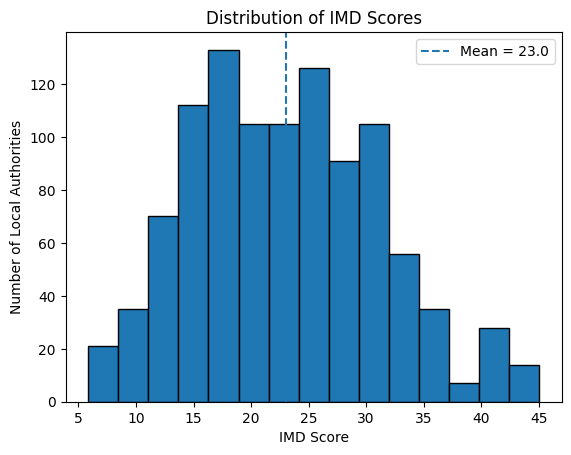

In [8]:
plt.hist(df_q3["imd_score"], bins=15,edgecolor="black")
plt.xlabel("IMD Score")
plt.ylabel("Number of Local Authorities")
plt.title("Distribution of IMD Scores")
plt.axvline(df_q3["imd_score"].mean(),
            linestyle="--",
            label=f"Mean = {df_q3['imd_score'].mean():.1f}")

plt.legend()
plt.show()

The distribution of IMD scores is reasonably broad, ranging from approximately 6 to 45, with a mean score of 23.0. Most Local Authority observations are concentrated between IMD scores of 15 and 32, indicating moderate levels of deprivation.

The distribution appears roughly bell-shaped, although there is a small right tail representing a limited number of highly deprived authorities with IMD scores above 40. These observations were retained as they represent genuine differences in deprivation rather than data quality issues.

### Correlation between deprivation and subject performance

Two measures of deprivation were examined:

- Average IMD score, representing the overall level of deprivation within a Local Authority.
- Percentage of highly deprived LSOAs, representing the concentration of the most deprived neighbourhoods.

Comparing both measures helps determine whether the findings are robust to different ways of measuring deprivation.

In [26]:
corr_df = pd.DataFrame({
    "Subject": [subject_names[col] for col in subjects],
    "Corr(IMD)": [df_q3["imd_score"].corr(df_q3[col]) for col in subjects],
    "Corr(% Highly Deprived)": [df_q3["pct_highly_deprived"].corr(df_q3[col]) for col in subjects]
})

corr_df

,Subject,Corr(IMD),Corr(% Highly Deprived)
0,English,-0.520325,-0.525137
1,Maths,-0.614029,-0.613521
2,Science,-0.600584,-0.599225
3,Humanities,-0.595660,-0.586752
4,Languages,-0.310951,-0.359240


All EBacc subjects show a negative correlation with deprivation, indicating that attainment tends to be lower in more deprived Local Authorities.

Maths (-0.61), Science (-0.60) and Humanities (-0.60) show the strongest negative relationships with deprivation.  English occupies a middle position (-0.52). Languages show a substantially weaker correlation (-0.31), suggesting that language attainment may be more resilient to deprivation than other EBacc subjects.

Using the percentage of highly deprived neighbourhoods produced very similar results, suggesting that the findings are robust across different deprivation measures.

### Visual comparison of subject resilience

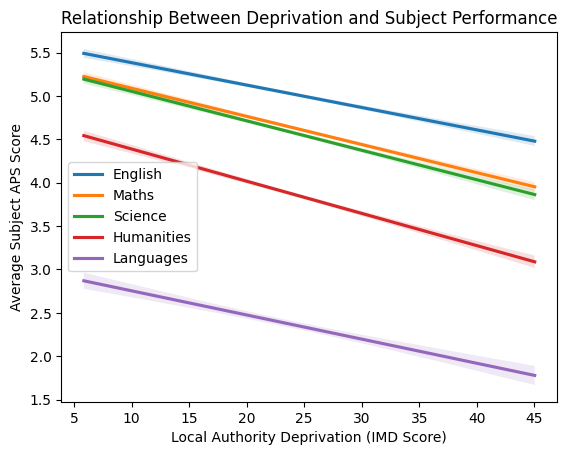

In [10]:
for col in subjects:
    sns.regplot(
        data=df_q3,
        x="imd_score",
        y=col,
        scatter=False,
        label=subject_names[col]
    )
plt.xlabel("Local Authority Deprivation (IMD Score)")
plt.ylabel("Average Subject APS Score")
plt.title("Relationship Between Deprivation and Subject Performance")
plt.legend()
plt.show()

The regression lines confirm a clear negative relationship between deprivation and attainment across all subjects.

The slope for Languages is noticeably flatter than for the other subjects, indicating that language performance declines less as deprivation increases. In contrast, Maths, Science and Humanities display similar downward trends, suggesting that they are more strongly affected by deprivation.

This provides initial evidence that Languages may be the most resilient EBacc subject.

### Subject performance across deprivation groups

The correlation analysis demonstrated a negative relationship between deprivation and attainment across all EBacc subjects. To view this relationship from a different perspective, Local Authorities were divided into ten equally sized deprivation groups (deciles) based on their IMD scores, ranging from the least deprived 10% of authorities to the most deprived 10%.

Average APS scores were then calculated for each subject within each deprivation group. This provides an alternative perspective on how attainment changes across the deprivation spectrum and allows comparison of attainment gaps between the least and most deprived authorities.

In [22]:

df_q3["imd_group"] = pd.qcut(
    df_q3["imd_score"],
    q=10,
    labels=["Least deprived","D2","D3","D4","D5","D6","D7","D8", "D9","Most deprived"]
)
group_means = df_q3.groupby("imd_group")[subjects].mean().round(2).rename(columns=subject_names)
group_means.loc["Gap"]  = (group_means.loc["Least deprived"]- group_means.loc["Most deprived"]).round(2)

group_means

,English,Maths,Science,Humanities,Languages
imd_group,,,,,
Least deprived,5.33,5.05,5.00,4.34,2.62
D2,5.26,4.94,4.94,4.20,2.65
D3,5.22,4.88,4.82,4.19,2.60
D4,5.02,4.71,4.65,3.93,2.28
D5,5.21,4.81,4.79,4.04,2.69
D6,5.06,4.64,4.58,3.89,2.45
D7,4.95,4.50,4.44,3.76,2.29
D8,5.00,4.59,4.49,3.79,2.41
D9,4.82,4.38,4.32,3.61,2.03


Average attainment decreases steadily as deprivation increases across all subjects. For example, English APS falls from 5.33 in the least deprived authorities to 4.60 in the most deprived authorities. Similar declines are observed for Maths, Science, Humanities and Languages.

Humanities show the largest attainment gap (1.05 APS points), followed by Science (0.91) and Maths (0.90). English shows the smallest gap (0.73), closely followed by Languages (0.75).

These results support the correlation analysis, which suggested that English and Languages are more resilient to deprivation than Maths, Science and Humanities.

### Subject participation across deprivation groups

Attainment may not tell the whole story. If some subjects are entered by a smaller and potentially more selective group of pupils, this may influence the relationship between deprivation and performance.

To investigate this, average subject entry rates were compared across deprivation groups.

In [23]:

group_means_pct = df_q3.groupby("imd_group")[entering].mean().round(2).rename(columns=subject_names)
group_means_pct.loc["Gap"]  = (group_means_pct.loc["Least deprived"]- group_means_pct.loc["Most deprived"]).round(2)
group_means_pct

,Eng entering %,Math entering %,Sci entering %,Hum entering %,Lang entering %
imd_group,,,,,
Least deprived,95.55,97.28,95.55,82.96,48.61
D2,95.46,97.33,95.99,82.11,49.45
D3,95.64,97.30,95.79,84.00,49.64
D4,95.10,97.07,95.40,81.82,43.55
D5,95.40,96.91,95.35,81.83,51.82
D6,95.60,97.12,95.65,82.32,47.39
D7,94.55,96.57,94.67,81.23,45.00
D8,94.37,96.44,94.11,80.47,46.56
D9,94.17,96.44,94.22,80.16,40.30


Entry rates for English, Maths and Science remain consistently high across all deprivation groups, reflecting their status as core GCSE subjects. Participation in these subjects decreases only slightly between the least deprived and most deprived authorities.

Humanities show a modest decline, falling from 83.0% in the least deprived authorities to 78% in the most deprived authorities.

Languages display the largest reduction in participation. The average language entry rate falls from 48.6% in the least deprived authorities to 38.7% in the most deprived authorities—a decline of almost 10 percentage points (around 20% relative decrease). This suggests that pupils in more deprived areas are substantially less likely to study a language qualification.This may help explain why language attainment appears relatively resilient to deprivation

## Conclusion

Deprivation is negatively associated with attainment across all EBacc subjects.

Correlation analysis identified Languages as the subject least associated with deprivation, while the attainment-gap analysis suggested that English experiences the smallest difference between the least and most deprived authorities. Both approaches consistently indicate that English and Languages are more resilient to deprivation than Maths, Science and Humanities.

Participation analysis showed that Languages are entered by a substantially smaller proportion of pupils than other EBacc subjects, particularly in more deprived authorities. This may contribute to the apparent resilience of language attainment, although further investigation would be required to confirm this explanation.

Overall, deprivation appears to have a stronger relationship with attainment than with subject participation.